# MIT-BIH Data Exploration\n\nLoad record `100` from the MIT-BIH Arrhythmia Database and plot the first 500 samples of its signal.

In [1]:
import wfdb
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("..") / "data" / "raw" / "mit-bih-arrhythmia-database-1.0.0"
RECORD_NAME = "100"

In [2]:
record = wfdb.rdrecord(str(DATA_DIR / RECORD_NAME))
print(f"Record: {record.record_name}")
print(f"Signals: {record.sig_name}")
print(f"Sampling frequency: {record.fs} Hz")
print(f"Signal shape: {record.p_signal.shape}")

Record: 100
Signals: ['MLII', 'V5']
Sampling frequency: 360 Hz
Signal shape: (650000, 2)


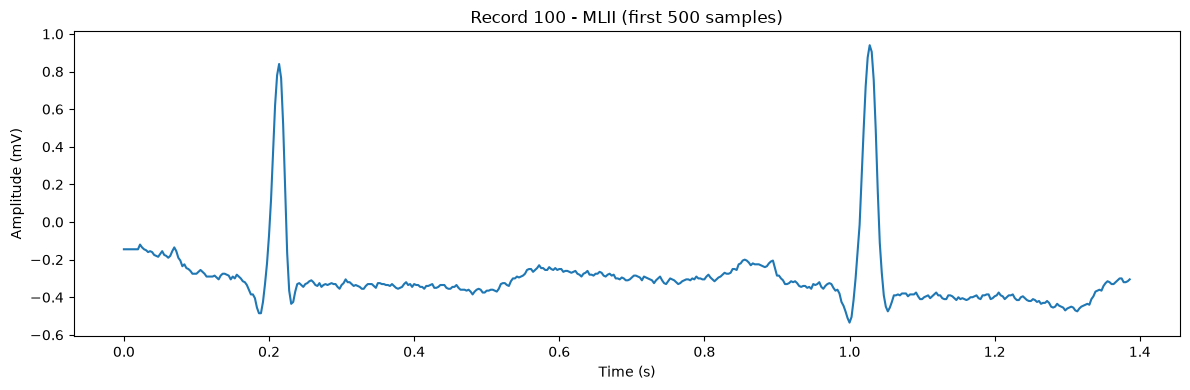

In [3]:
N_SAMPLES = 500
signal = record.p_signal[:N_SAMPLES, 0]
channel_name = record.sig_name[0]
time = [i / record.fs for i in range(N_SAMPLES)]

plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.title(f"Record {RECORD_NAME} - {channel_name} (first {N_SAMPLES} samples)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.tight_layout()
plt.show()

## Browse beats by AAMI class

Plot one example beat window for each AAMI EC57 superclass (`N`, `S`, `V`, `F`) from `data/processed/beat_windows.npy` / `beat_metadata.csv`. (`Q` is excluded upstream in preprocessing -- too few examples to be meaningful.)

Found 88265 beats with class 'N'
Found 2769 beats with class 'S'
Found 6965 beats with class 'V'
Found 798 beats with class 'F'


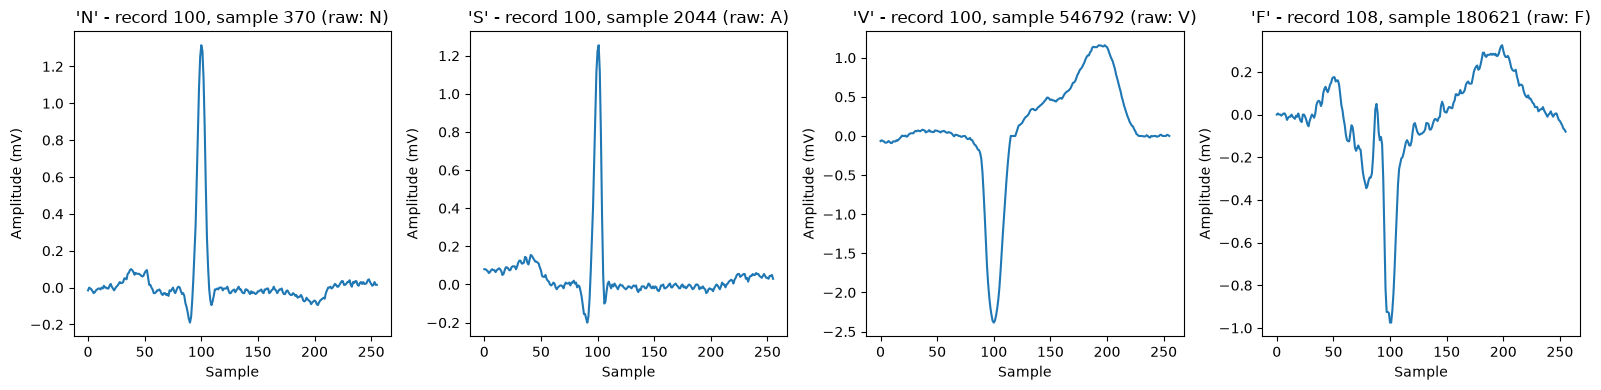

In [4]:
import csv
import numpy as np

PROCESSED_DIR = Path("..") / "data" / "processed"

beat_windows = np.load(PROCESSED_DIR / "beat_windows.npy")
with open(PROCESSED_DIR / "beat_metadata.csv", newline="") as f:
    beat_meta = list(csv.DictReader(f))

AAMI_CLASSES = ["N", "S", "V", "F"]

fig, axes = plt.subplots(1, len(AAMI_CLASSES), figsize=(4 * len(AAMI_CLASSES), 4))
for ax, cls in zip(axes, AAMI_CLASSES):
    matching = [row for row in beat_meta if row["aami_label"] == cls]
    print(f"Found {len(matching)} beats with class '{cls}'")
    if not matching:
        ax.set_title(f"class '{cls}' (no examples)")
        continue

    row = matching[0]
    window = beat_windows[int(row["window_idx"])]
    ax.plot(window)
    ax.set_title(f"'{cls}' - record {row['record_id']}, sample {row['r_peak_sample']} (raw: {row['raw_symbol']})")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude (mV)")
plt.tight_layout()
plt.show()

## Sanity-check: does detrending over-smooth genuine morphology?

`remove_baseline_wander` (see `src/ecgvae/data/preprocessing.py`) uses a two-stage
median filter (~200ms then ~600ms) to estimate and subtract baseline wander. The
600ms stage-2 window is wide enough to remove P/T waves, but if a beat's ST
segment happens to be unusually long, that same window could start absorbing
genuine low-frequency morphology (e.g. an ST-segment shift) into the "baseline"
estimate and subtract it out along with the wander.

That risk isn't visible from the math alone, so check it visually on a noisy
record. Record `207` had the most non-beat annotations of any record explored so
far, making it a good stress test. We plot a beat's raw signal, the estimated
baseline (what gets subtracted), and the detrended result together.

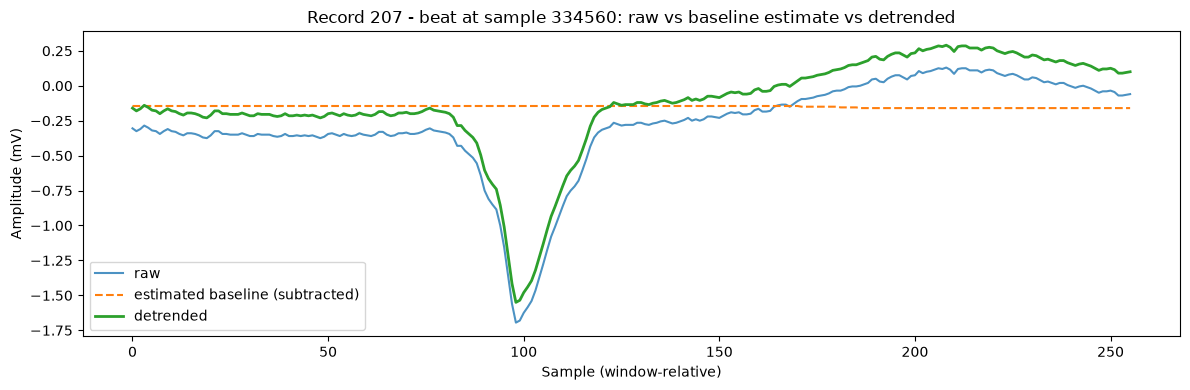

In [ ]:
from scipy.signal import medfilt

from ecgvae.data.preprocessing import _odd_kernel_size, WINDOW_PRE, WINDOW_POST

NOISY_RECORD = "207"

record_noisy = wfdb.rdrecord(str(DATA_DIR / NOISY_RECORD))
ann_noisy = wfdb.rdann(str(DATA_DIR / NOISY_RECORD), "atr")

raw_signal = record_noisy.p_signal[:, 0]
fs = record_noisy.fs

# Reproduce the two stages manually so we can inspect the intermediate
# baseline estimate, not just the final detrended signal.
k1 = _odd_kernel_size(0.2, fs)  # ~200ms, stage 1: removes QRS
k2 = _odd_kernel_size(0.6, fs)  # ~600ms, stage 2: removes P/T -> baseline estimate
stage1 = medfilt(raw_signal, kernel_size=k1)
baseline = medfilt(stage1, kernel_size=k2)
detrended_signal = raw_signal - baseline

# Pick a beat away from the record boundaries so the window is fully in range.
candidate_idxs = [
    i for i, s in enumerate(ann_noisy.sample)
    if s - WINDOW_PRE >= 0 and s + WINDOW_POST <= len(raw_signal)
]
beat_idx = candidate_idxs[len(candidate_idxs) // 2]
r_peak = ann_noisy.sample[beat_idx]
start, end = r_peak - WINDOW_PRE, r_peak + WINDOW_POST

plt.figure(figsize=(12, 4))
plt.plot(raw_signal[start:end], label="raw", alpha=0.8)
plt.plot(baseline[start:end], label="estimated baseline (subtracted)", linestyle="--")
plt.plot(detrended_signal[start:end], label="detrended", linewidth=2)
plt.title(f"Record {NOISY_RECORD} - beat at sample {r_peak}: raw vs baseline estimate vs detrended")
plt.xlabel("Sample (window-relative)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.tight_layout()
plt.show()

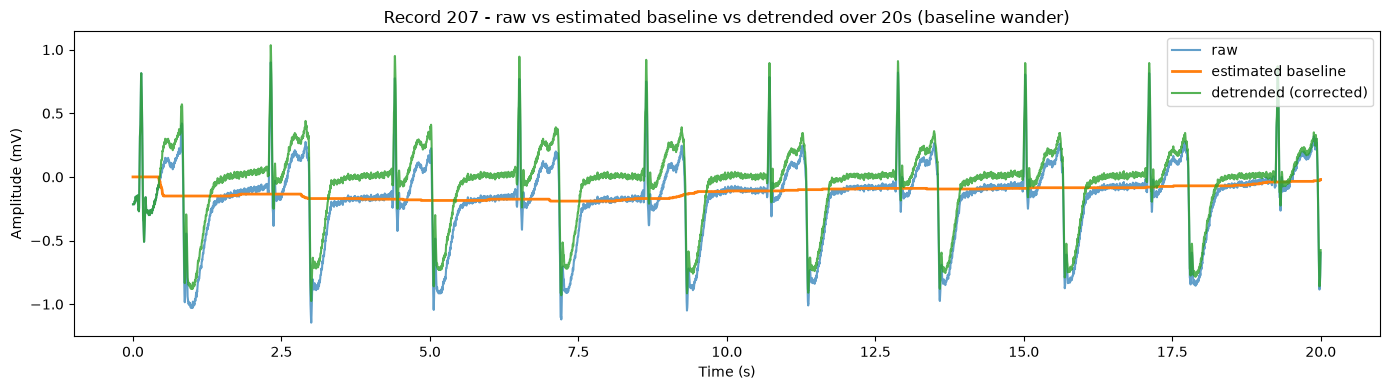

In [6]:
DRIFT_SECONDS = 20
n_drift_samples = int(DRIFT_SECONDS * fs)
drift_time = [i / fs for i in range(n_drift_samples)]

plt.figure(figsize=(14, 4))
plt.plot(drift_time, raw_signal[:n_drift_samples], label="raw", alpha=0.7)
plt.plot(drift_time, baseline[:n_drift_samples], label="estimated baseline", linewidth=2)
plt.plot(drift_time, detrended_signal[:n_drift_samples], label="detrended (corrected)", alpha=0.8)
plt.title(f"Record {NOISY_RECORD} - raw vs estimated baseline vs detrended over {DRIFT_SECONDS}s (baseline wander)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.tight_layout()
plt.show()

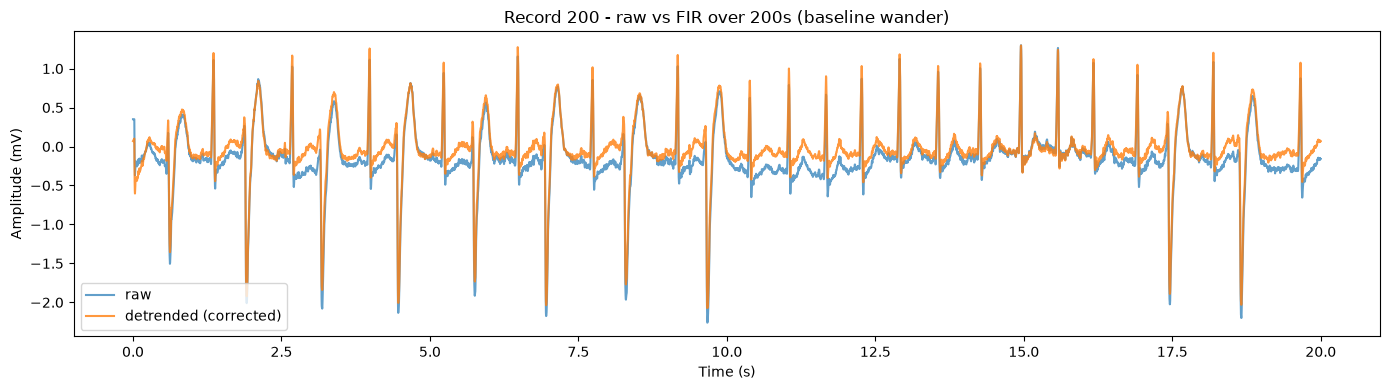

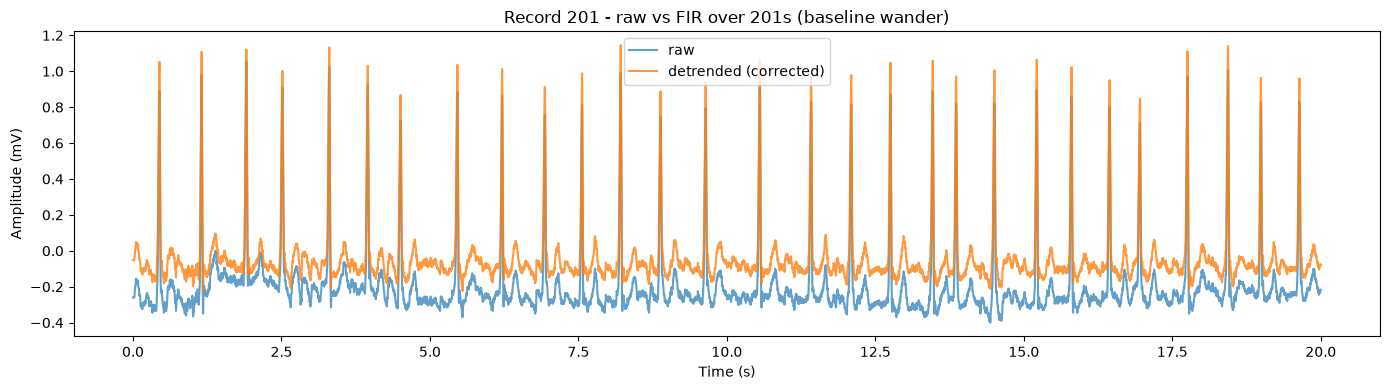

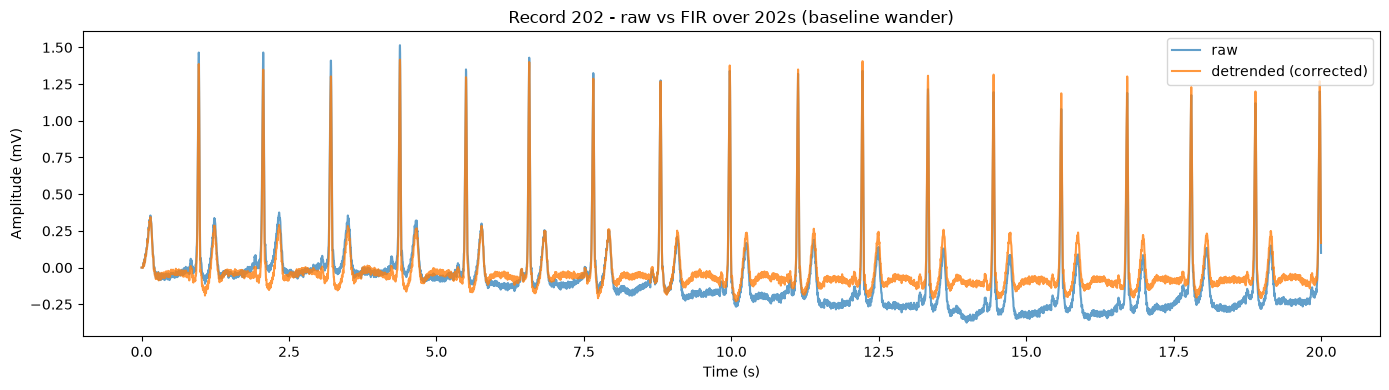

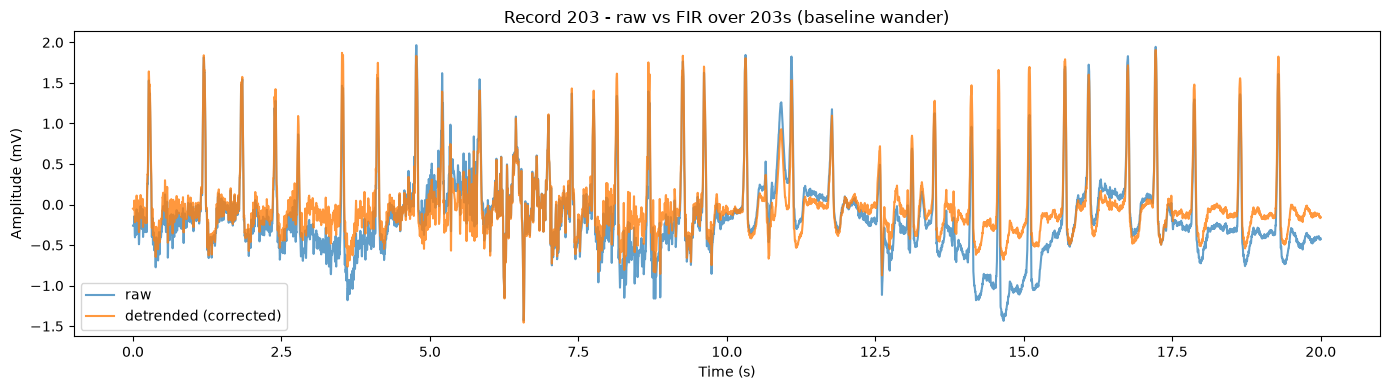

Skipping 204: not present locally (..\data\raw\mit-bih-arrhythmia-database-1.0.0\204.hea)


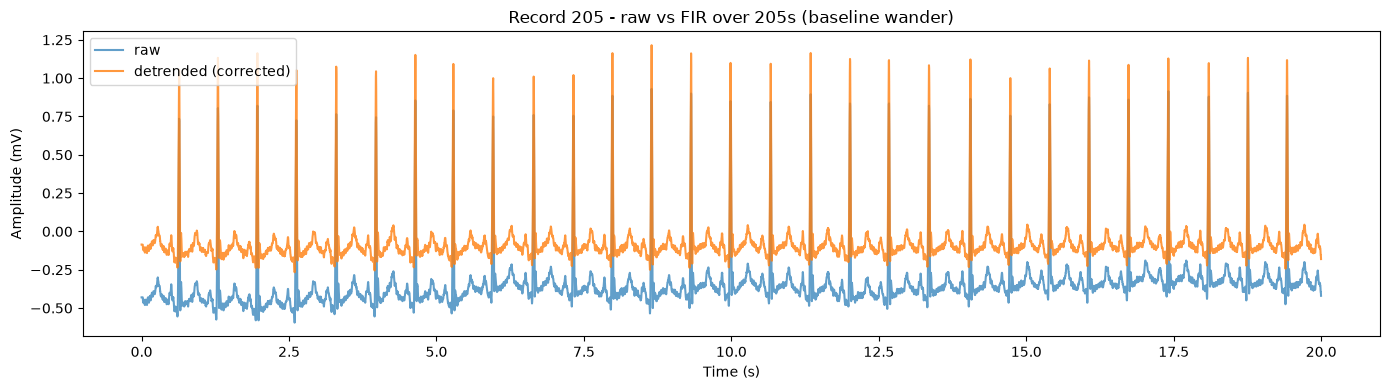

Skipping 206: not present locally (..\data\raw\mit-bih-arrhythmia-database-1.0.0\206.hea)


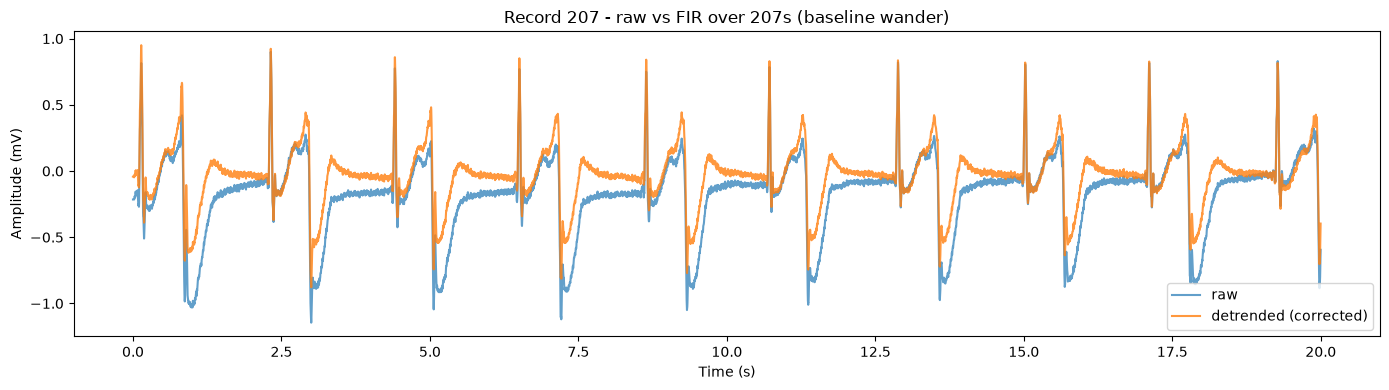

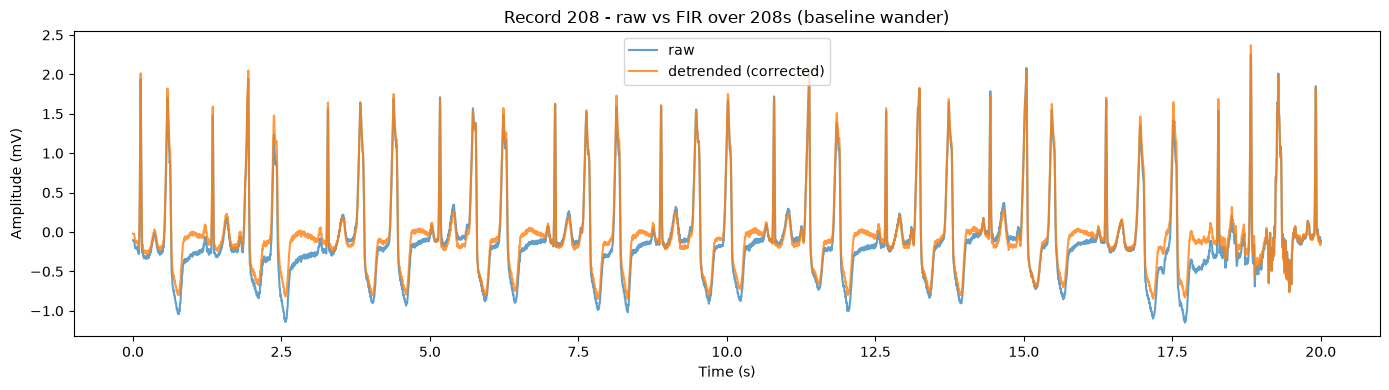

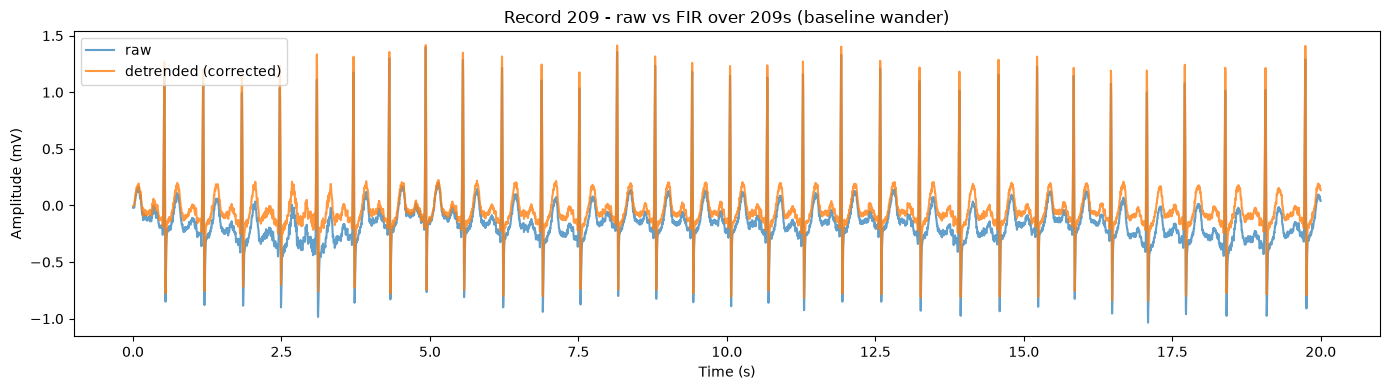

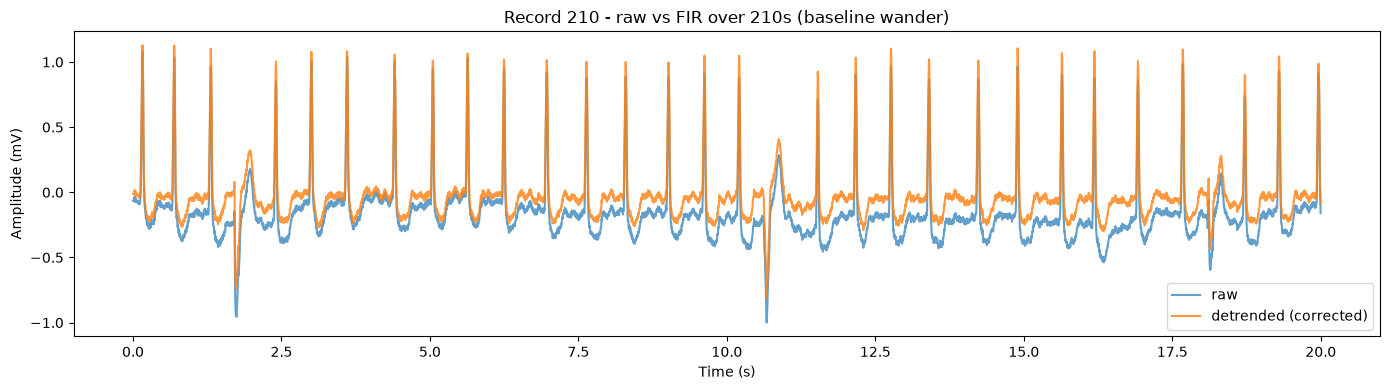

Skipping 211: not present locally (..\data\raw\mit-bih-arrhythmia-database-1.0.0\211.hea)


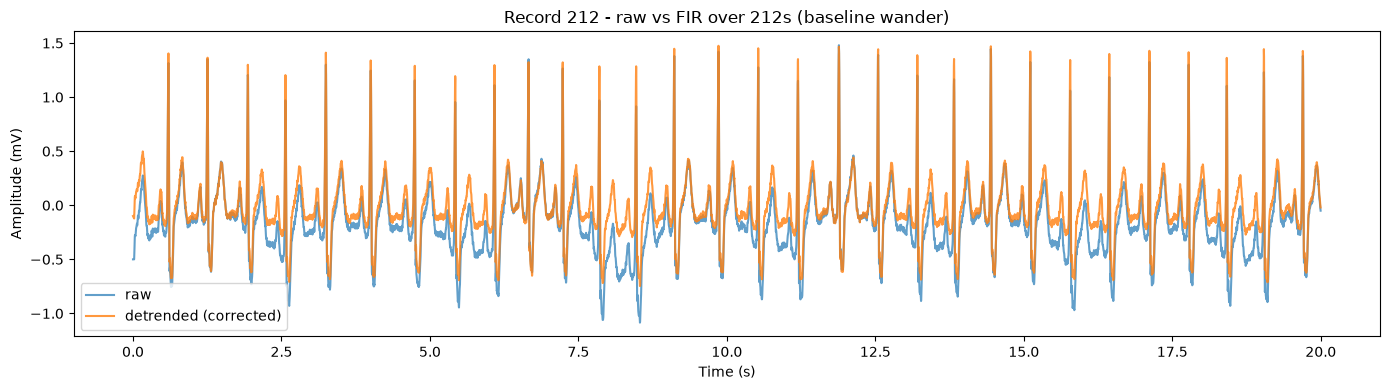

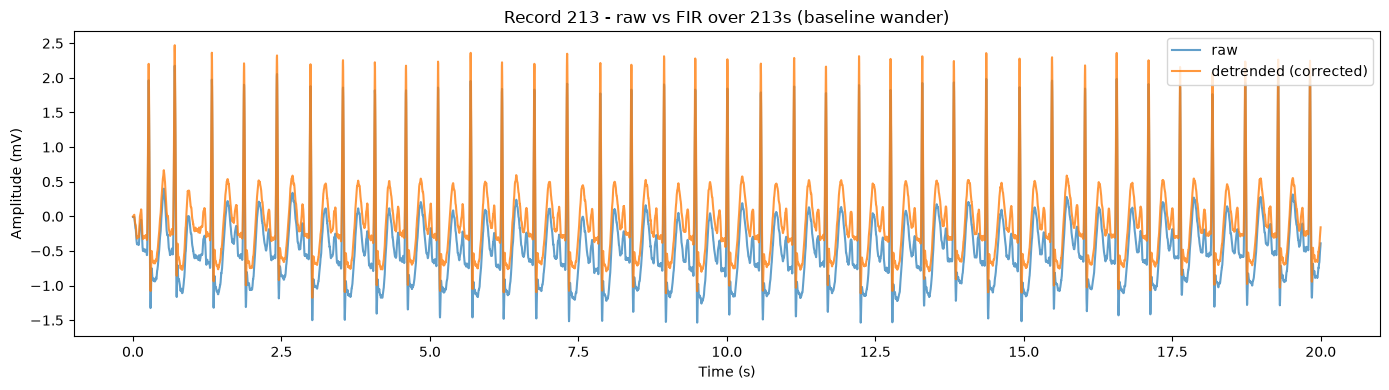

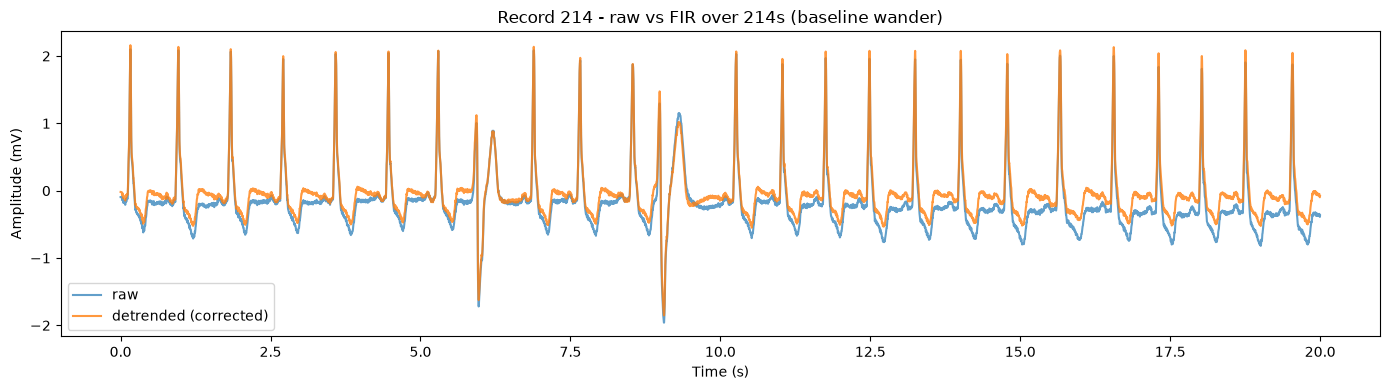

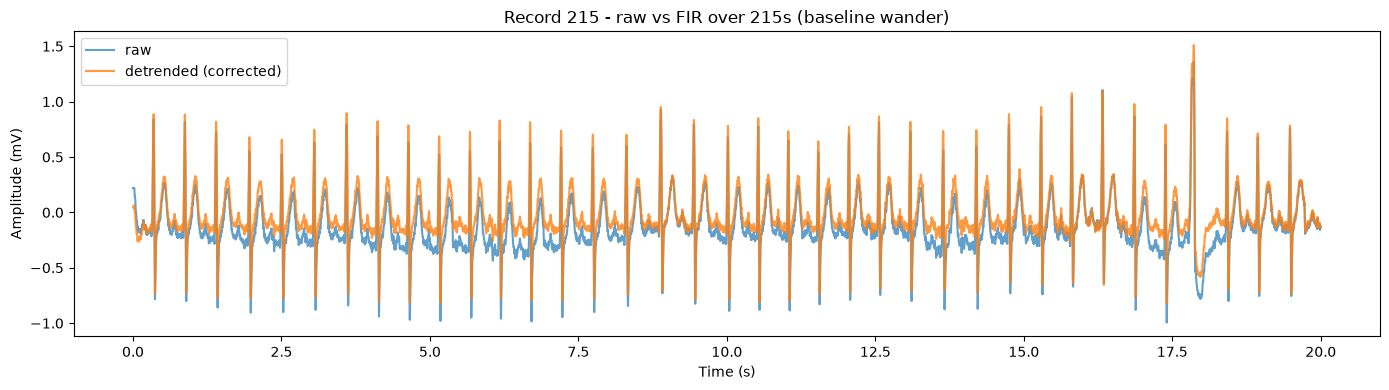

Skipping 216: not present locally (..\data\raw\mit-bih-arrhythmia-database-1.0.0\216.hea)


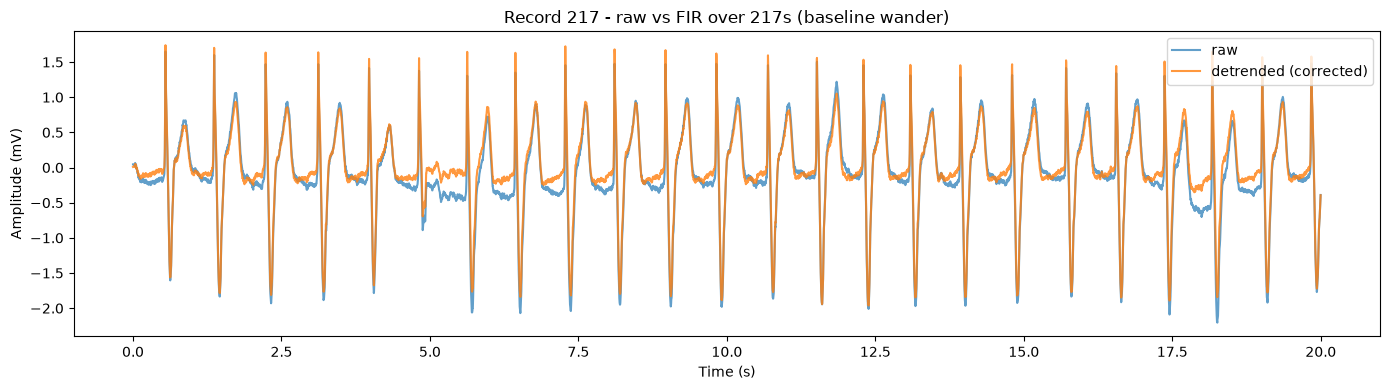

Skipping 218: not present locally (..\data\raw\mit-bih-arrhythmia-database-1.0.0\218.hea)


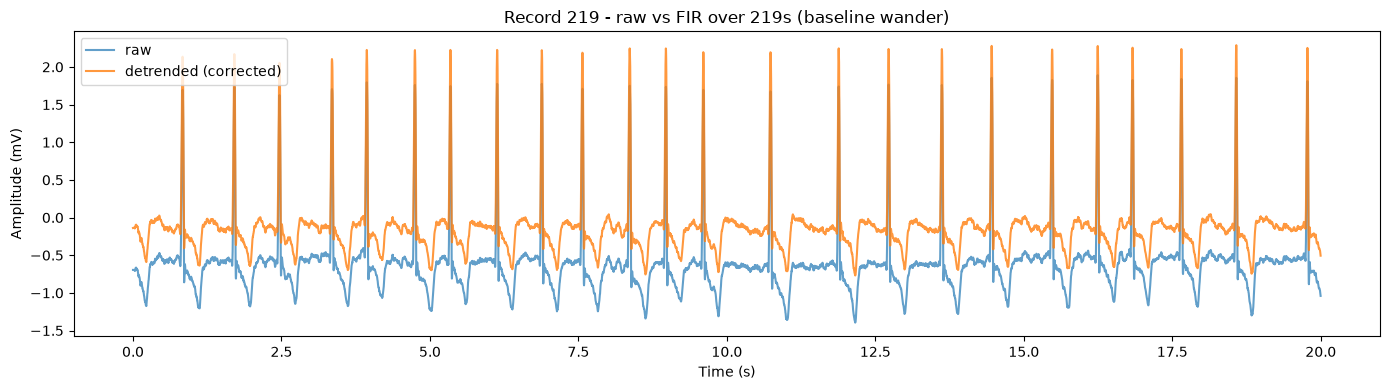

In [7]:
from scipy.signal import firwin, filtfilt

def remove_baseline_wander_fir(signal, fs=360, cutoff=0.5, numtaps=401):
    """
    High-pass FIR filter to remove baseline wander.
    cutoff: Hz, below this is considered baseline wander (default 0.5 Hz is standard).
    numtaps: filter length; must be odd for a Type I linear-phase FIR high-pass.
             Larger = sharper cutoff, but needs more signal padding at edges.
    """
    fir_coeff = firwin(numtaps, cutoff, fs=fs, pass_zero=False)  # high-pass
    return filtfilt(fir_coeff, [1.0], signal)

records = [str(_) for _ in range(200, 220)]  # Example range of records to process
for record_id in records:
    record_path = DATA_DIR / f"{record_id}.hea"
    if not record_path.exists():
        print(f"Skipping {record_id}: not present locally ({record_path})")
        continue

    record_noisy = wfdb.rdrecord(str(DATA_DIR / record_id))
    ann_noisy = wfdb.rdann(str(DATA_DIR / record_id), "atr")

    raw_signal = record_noisy.p_signal[:, 0]

    filtered_signal = remove_baseline_wander_fir(raw_signal, fs=record_noisy.fs)
    plt.figure(figsize=(14, 4))
    plt.plot(drift_time, raw_signal[:n_drift_samples], label="raw", alpha=0.7)
    plt.plot(drift_time, filtered_signal[:n_drift_samples], label="detrended (corrected)", alpha=0.8)
    plt.title(f"Record {record_id} - raw vs FIR over {record_id}s (baseline wander)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.legend()
    plt.tight_layout()
    plt.show()


Single beat of 207 after FIR

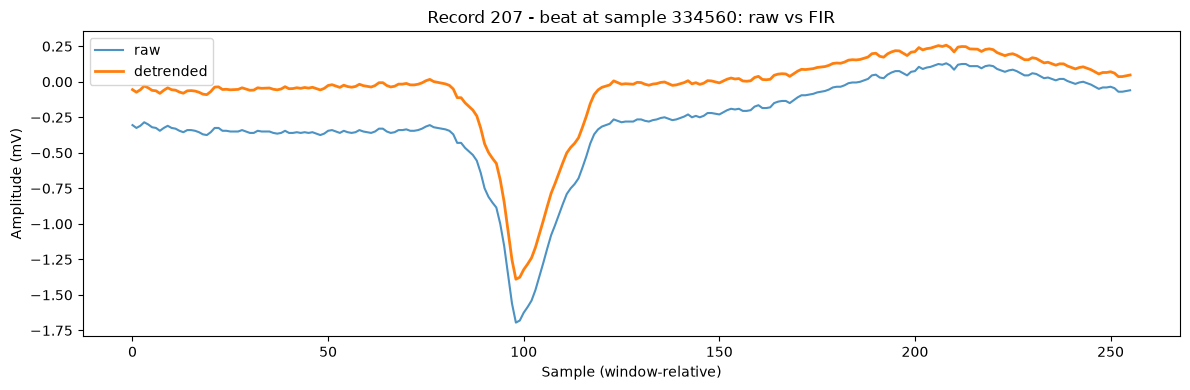

In [8]:
record_id = "207"  # Example record to inspect
record_noisy = wfdb.rdrecord(str(DATA_DIR / record_id))
ann_noisy = wfdb.rdann(str(DATA_DIR / record_id), "atr")

raw_signal = record_noisy.p_signal[:, 0]

filtered_signal = remove_baseline_wander_fir(raw_signal, fs=record_noisy.fs)

plt.figure(figsize=(12, 4))
plt.plot(raw_signal[start:end], label="raw", alpha=0.8)
plt.plot(filtered_signal[start:end], label="detrended", linewidth=2)
plt.title(f"Record {record_id} - beat at sample {r_peak}: raw vs FIR")
plt.xlabel("Sample (window-relative)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.tight_layout()
plt.show()